In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_tc_labels = pd.read_csv('../data/raw/medical_tc_labels.csv')
df_tc_labels.info()

In [ ]:
df_tc_labels.head(5)

In [ ]:
df_tc_test = pd.read_csv('../data/raw/medical_tc_test.csv')
df_tc_test.info()

In [ ]:
x = df_tc_test.groupby('condition_label')['medical_abstract'].count()
print(x)

In [ ]:
x.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Total de medical_abstract por condition_label")
plt.xlabel("condition label")
plt.ylabel("total medical abstract")
plt.tight_layout
plt.show()

In [ ]:
sns.countplot(data=df_tc_test, x='condition_label',palette='pastel')
plt.title("Total de medical_abstract por condition_label")
plt.show()

In [ ]:
df_tc_train = pd.read_csv('../data/raw/medical_tc_train.csv')
df_tc_train.info()

In [ ]:
sns.countplot(data=df_tc_train, x='condition_label',palette='pastel')
plt.title("Total de medical_abstract por condition_label")
plt.show()

In [ ]:
df_train_merge = df_tc_train.merge(df_tc_labels, how='inner', on='condition_label')
df_train_merge.to_csv('../data/processed/df_train_merged.csv')

In [ ]:
df_test_merge = df_tc_test.merge(df_tc_labels, how='inner', on='condition_label')
df_test_merge.to_csv('../data/processed/df_test_merged.csv')

In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")
print(nlp)

In [ ]:
documento = nlp("im learnin english")
documento

In [ ]:
for token in documento:
    print(token.text, token.pos_)

Lematização: lema de uma palavra de acordo com seu significado no dicionarios
Stemização: extrair o radical das palavras

In [ ]:
documento_df = nlp(str(df_train_merge['medical_abstract']))

In [ ]:
for token in documento_df:
    print(token.text, token.pos_)

Reconhecendo entidades nomeadas

NER - named-entity recognition: encontrar entidades no textto

In [ ]:
documento_df = nlp(str(df_train_merge['medical_abstract']))

for entidade in documento_df.ents:
    print(entidade.text, entidade.label_)

In [ ]:
from spacy import displacy
displacy.render(documento_df, style='ent', jupyter=True)

In [ ]:
documento_df = nlp(str(df_train_merge['medical_abstract']))

for entidade in documento_df.ents:
    print(entidade.text, entidade.label_)

In [ ]:
from spacy import displacy
displacy.render(documento_df, style='ent', jupyter=True)

In [ ]:
import nltk
nltk.download('rslp')

In [ ]:
stemmet = nltk.stem.RSLPStemmer()
stemmet.stem('aprendendo')

In [ ]:
for token in documento_df:
    print(token.text, token.lemma, stemmet.stem(token.text))

In [ ]:
# stopwords = palavras que nao agregam
from spacy.lang.en.stop_words import STOP_WORDS
len(STOP_WORDS)

In [ ]:
nlp.vocab['would'].is_stop

In [ ]:
# Funções de pre processamento: retirada e pontuações, remocao de stop words
from spacy.lang.en.stop_words import STOP_WORDS
import string

stop_words = STOP_WORDS
print(stop_words)

pontuacoes = string.punctuation
print(pontuacoes)

In [ ]:
len(stop_words)

In [ ]:
pln = spacy.load("en_core_web_sm")
pln

In [ ]:
def pre_processamento(texto):
    texto = texto.lower()
    documento = pln(texto)

    lista = []
    for token in documento:
        lista.append(token.lemma_)

    lista = [palavra for palavra in lista if palavra not in stop_words and palavra not in pontuacoes]
    lista = ' '.join([str(elemento) for elemento in lista if not elemento.isdigit()])
    return lista

In [ ]:
teste = pre_processamento('im learning, the english ; ')

print(teste)

In [ ]:
df_train_merge.head(10)

In [ ]:
df_train_merge['medical_abstract']  = df_train_merge['medical_abstract'].apply(pre_processamento)

In [34]:
df_train_merge.to_csv('../data/processed/df_train_preprocessed.csv')

In [35]:
df_train_preprocessed = pd.read_csv('../data/processed/df_train_preprocessed.csv')
df_train_preprocessed.head(10)

,Unnamed: 0,condition_label,medical_abstract,condition_name
0,0,5,Tissue changes around loose prostheses. A cani...,general pathological conditions
1,1,1,Neuropeptide Y and neuron-specific enolase lev...,neoplasms
2,2,2,"Sexually transmitted diseases of the colon, re...",digestive system diseases
3,3,1,Lipolytic factors associated with murine and h...,neoplasms
4,4,3,Does carotid restenosis predict an increased r...,nervous system diseases
5,5,3,The shoulder in multiple epiphyseal dysplasia....,nervous system diseases
6,6,2,The management of postoperative chylous ascite...,digestive system diseases
7,7,4,Pharmacomechanical thrombolysis and angioplast...,cardiovascular diseases
8,8,5,Color Doppler diagnosis of mechanical prosthet...,general pathological conditions
9,9,5,Noninvasive diagnosis of right-sided extracard...,general pathological conditions


In [36]:
df_train_final = []

for medical_abstract, condition_name in zip(df_train_preprocessed['medical_abstract'], df_train_preprocessed['condition_name']):
    if condition_name == 'neoplasms':
        dic = ({'neoplasms': True, 'digestive system diseases': False, 'nervous system diseases':False, 'cardiovascular diseases': False, 'general pathological conditions': False})
    elif condition_name == 'digestive system diseases':
        dic = ({'neoplasms': False, 'digestive system diseases': True, 'nervous system diseases':False, 'cardiovascular diseases': False, 'general pathological conditions': False})   
    elif condition_name == 'nervous system diseases':
            dic = ({'neoplasms': False, 'digestive system diseases': False, 'nervous system diseases':True, 'cardiovascular diseases': False, 'general pathological conditions': False})
    elif condition_name == 'cardiovascular diseases':
                dic = ({'neoplasms': False, 'digestive system diseases': False, 'nervous system diseases':False, 'cardiovascular diseases': True, 'general pathological conditions': False})
    elif condition_name == 'general pathological conditions':
                dic = ({'neoplasms': False, 'digestive system diseases': False, 'nervous system diseases':False, 'cardiovascular diseases': False, 'general pathological conditions': True})     

    df_train_final.append([medical_abstract, dic.copy()])             

In [37]:
df_train_final[0][1]

{'neoplasms': False,
 'digestive system diseases': False,
 'nervous system diseases': False,
 'cardiovascular diseases': False,
 'general pathological conditions': True}

In [38]:
type(df_train_final[0][1])

dict

In [45]:
import random
import spacy
from spacy.training.example import Example
from spacy.util import compounding, minibatch

# Criar modelo em branco
modelo = spacy.blank("en")

# Adicionar componente de classificação de texto
categorias = modelo.add_pipe("textcat", last=True)
categorias.add_label("neoplasms")
categorias.add_label("digestive system diseases")
categorias.add_label("nervous system diseases")
categorias.add_label("cardiovascular diseases")
categorias.add_label("general pathological conditions")

# Inicializar otimizador DEPOIS de adicionar o textcat
optimizer = modelo.initialize()

historico = []

batch_sizes = compounding(32.0, 512.0, 1.001)

for epoca in range(10):
    random.shuffle(df_train_final)
    losses = {}

    # Criar batches
    for batch in spacy.util.minibatch(df_train_final, size=batch_sizes):
        examples = []
        for texto, entities in batch:
            doc = modelo.make_doc(texto)
            examples.append(Example.from_dict(doc, {"cats": entities}))

        # Atualizar o modelo com os exemplos
        modelo.update(examples, sgd=optimizer, losses=losses)

    # Mostrar perdas acumuladas da época
    if epoca % 5 == 0:
        print(f"Época {epoca} - Losses: {losses}")
        historico.append(losses.copy())


Época 0 - Losses: {'textcat': 38.71088317036629}
Época 5 - Losses: {'textcat': 8.137928865849972}


In [46]:
modelo.to_disk('modelo')

Text(0, 0.5, 'erro')

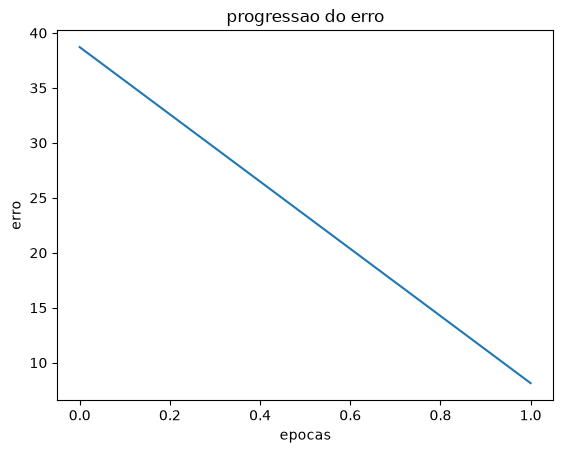

In [47]:
historico_loss = []
for i in historico:
    historico_loss.append(i.get('textcat'))

import numpy as np
historico_loss = np.array(historico_loss)
historico_loss


import matplotlib.pyplot as plt

plt.plot(historico_loss)
plt.title('progressao do erro')
plt.xlabel('epocas')
plt.ylabel('erro')

In [48]:
modelo_carregado = spacy.load("modelo") 
modelo_carregado


frase = 'I have a headache.'

frase = pre_processamento(frase)
frase

'I headache'

In [49]:
previsao = modelo_carregado(frase)
previsao
previsao.cats

{'neoplasms': 0.0003584334335755557,
 'digestive system diseases': 0.003702777437865734,
 'nervous system diseases': 0.9656265377998352,
 'cardiovascular diseases': 9.617260366212577e-05,
 'general pathological conditions': 0.030216127634048462}